# Snow snotel comparison

In [1]:
# librariies
import xarray as xr
import numpy as np
import pandas as pd

from snobedo.snotel import SnotelLocations
from snobedo.snotel import SnotelLocations, CsvParser

from snobedo.lib.dask_utils import start_cluster, client_ip_and_port

from pathlib import Path, PurePath

import matplotlib.pyplot as plt

In [2]:
# paths
S_STORE = PurePath("/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/smeshr/net_HRRR_MODIS_SPIRES")
S_STORE = PurePath("/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/smeshr/net_HRRR_MODIS_SPIRES/net_solar_dsw3/wy2022")
# net_dswrf.MST.20211110.nc
SHARED_STORE2 = PurePath("/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit")
# toposplit_20220218.nc

SHARED_STORE_RUN = PurePath("/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/results/isnobal_simulations/hrrr_toposplit")
# erw_spires_dsw3_dlwrf/wy2022/erw_50m

SHARED_STORE = PurePath('/uufs/chpc.utah.edu/common/home/skiles-group1')
DATA_DIR = SHARED_STORE.joinpath('jmeyer')
SNOTEL_DIR = DATA_DIR.joinpath( 'Snotel')


year = 2022
water_year = f'wy{year}'

In [3]:
from pathlib import Path, PurePath
snotel_sites = SnotelLocations()
snotel_sites.load_from_json(SNOTEL_DIR / 'site-locations/snotel_sites.json')
snotel_sites.Irwin

SnotelSite(name='Irwin', lon=[317131], lat=[4306375])

In [4]:
schofield_snotel_csv = pd.concat([
    CsvParser.file(
        SNOTEL_DIR / water_year / f'Schofield/usda-csv/{year}-Schofield-Pass.csv',
    )
]).shift(22, freq='h')

butte_snotel_csv = pd.concat([
    CsvParser.file(
        SNOTEL_DIR /water_year  / f'Butte/usda-csv/{year}-Butte.csv',
    ),
]).shift(22, freq='h')

taylor_snotel_csv = pd.concat([
    CsvParser.file(
        SNOTEL_DIR / water_year / f'Taylor/usda-csv/{year}-Upper-Taylor.csv',
    )
]).shift(22, freq='h')

irwin_csv = pd.concat([
    CsvParser.file(
        SNOTEL_DIR / water_year / f'Irwin/usda-csv/{year}-Irwin.csv',
    )
])

irwin_csv['Depth(m)'] = irwin_csv['Depth(m)'] / 10

In [5]:
from dask.distributed import Client
from dask_jobqueue import SLURMCluster

cluster = SLURMCluster(
    cores=8,
    processes=4,
    memory="32GB",
    account="notchpeak-shared-short", # project
    queue="notchpeak-shared-short",
    walltime="2:00:00",
)

# Scale the cluster — adjust this based on your workload
cluster.scale(jobs=2)  # e.g., 2 jobs → 2 × 8 = 16 cores total

client = Client(cluster)  # Attach Dask client to the cluster

In [7]:
import os
os.path.isdir('/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/results/isnobal_simulations/hrrr_toposplit/sw/erw_spires_dsw1')

True

In [8]:
base_path1 =  '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/results/isnobal_simulations/hrrr_toposplit/sw/erw_spires_dsw1'
base_path3 =  '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/results/isnobal_simulations/hrrr_toposplit/sw/erw_spires_dsw3'
base_path3h =  '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/results/isnobal_simulations/hrrr_toposplit/sw/erw_spires_dsw3h/'

d1_pattern = f"{base_path1}/{water_year}/erw_50m/run*/snow.nc"
d3_pattern = f"{base_path3}/{water_year}/erw_50m/run*/snow.nc"
d3h_pattern = f"{base_path3h}/{water_year}/erw_50m/run*/snow.nc"

snow_dsw3 = xr.open_mfdataset(
    d3_pattern,
    combine='by_coords',         
    parallel=True,               
    chunks={'time': 24},         
    preprocess=lambda ds: ds['thickness']
)

snow_dsw3h = xr.open_mfdataset(
    d3h_pattern,
    combine='by_coords',         
    parallel=True,               
    chunks={'time': 24},         
    preprocess=lambda ds: ds['thickness']
)

snow_dsw1 = xr.open_mfdataset(
    d1_pattern,
    combine='by_coords',         
    parallel=True,               
    chunks={'time': 24},         
    preprocess=lambda ds: ds['thickness']
)


print(d3_pattern)

/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/results/isnobal_simulations/hrrr_toposplit/sw/erw_spires_dsw3/wy2022/erw_50m/run*/snow.nc


In [9]:
base_path_ghi =  '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/results/isnobal_simulations/hrrr_toposplit/sw/erw_spires_ghi'

ghi_pattern = f"{base_path1}/{water_year}/erw_50m/run*/snow.nc"

snow_ghi = xr.open_mfdataset(
    ghi_pattern,
    combine='by_coords',         
    parallel=True,               
    chunks={'time': 24},         
    preprocess=lambda ds: ds['thickness']
)

In [10]:
butte_snobal_ghi = snow_ghi.sel(x=snotel_sites.Butte.lon, y=snotel_sites.Butte.lat, method='nearest').compute()
schofield_snobal_ghi = snow_ghi.sel(x=snotel_sites.Schofield.lon, y=snotel_sites.Schofield.lat, method='nearest').compute()
taylor_snobal_ghi = snow_ghi.sel(x=snotel_sites.Taylor.lon, y=snotel_sites.Taylor.lat, method='nearest').compute()
irwin_snobal_ghi = snow_ghi.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').compute()

butte_snobal_dsw1 = snow_dsw1.sel(x=snotel_sites.Butte.lon, y=snotel_sites.Butte.lat, method='nearest').compute()
schofield_snobal_dsw1 = snow_dsw1.sel(x=snotel_sites.Schofield.lon, y=snotel_sites.Schofield.lat, method='nearest').compute()
taylor_snobal_dsw1 = snow_dsw1.sel(x=snotel_sites.Taylor.lon, y=snotel_sites.Taylor.lat, method='nearest').compute()
irwin_snobal_dsw1 = snow_dsw1.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').compute()

butte_snobal_dsw3 = snow_dsw3.sel(x=snotel_sites.Butte.lon, y=snotel_sites.Butte.lat, method='nearest').compute()
schofield_snobal_dsw3 = snow_dsw3.sel(x=snotel_sites.Schofield.lon, y=snotel_sites.Schofield.lat, method='nearest').compute()
taylor_snobal_dsw3 = snow_dsw3.sel(x=snotel_sites.Taylor.lon, y=snotel_sites.Taylor.lat, method='nearest').compute()
irwin_snobal_dsw3 = snow_dsw3.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').compute()

butte_snobal_dsw3h = snow_dsw3h.sel(x=snotel_sites.Butte.lon, y=snotel_sites.Butte.lat, method='nearest').compute()
schofield_snobal_dsw3h = snow_dsw3h.sel(x=snotel_sites.Schofield.lon, y=snotel_sites.Schofield.lat, method='nearest').compute()
taylor_snobal_dsw3h = snow_dsw3h.sel(x=snotel_sites.Taylor.lon, y=snotel_sites.Taylor.lat, method='nearest').compute()
irwin_snobal_dsw3h = snow_dsw3h.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').compute()

In [11]:
# # SAVE DATA
# import os

# # Create folder if it doesn't already exist
# save_dir = 'snotel-snow-depth'
# os.makedirs(save_dir, exist_ok=True)

# stations = ['butte', 'schofield', 'taylor', 'irwin']
# types = ['ghi', 'dsw1', 'dsw3', 'dsw3h']

# for station in stations:
#     for dtype in types:
#         var_name = f"{station}_snobal_{dtype}"
#         var_obj = globals().get(var_name)
#         if var_obj is not None:
#             save_path = os.path.join(save_dir, f"{var_name}.nc")
#             var_obj.to_netcdf(save_path)
#         else:
#             print(f"Variable {var_name} not found.")


In [12]:
# LOAD
save_dir = 'snotel-snow-depth'
stations = ['butte', 'schofield', 'taylor', 'irwin']
types = ['ghi', 'dsw1', 'dsw3', 'dsw3h']

for station in stations:
    for dtype in types:
        var_name = f"{station}_snobal_{dtype}"
        file_path = os.path.join(save_dir, f"{var_name}.nc")
        try:
            globals()[var_name] = xr.open_dataarray(file_path)  # or open_dataset if it was saved as a Dataset
        except FileNotFoundError:
            print(f"File not found: {file_path}")


# Plots

In [73]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.offsetbox import AnchoredText

STATION_LABEL = 'Station'
COLORS = {
        'Toposplit': 'cornflowerblue',
        # 'Toposplit-flat': 'lightcoral',
        'Base': 'sandybrown',
        STATION_LABEL: 'seagreen',    
}

def plot_site(data, ax, site_name):
    for key in data:
        if key == STATION_LABEL:
            continue
        
        ax.plot(
            data[key].time,
            data[key].data.flatten(),
            label=key, 
            color=COLORS[key], 
            alpha=0.9, lw=1
        )
    ax.plot(
        data[STATION_LABEL].index,
        data[STATION_LABEL].values,
        label=key, 
        color=COLORS[STATION_LABEL], 
        alpha=0.9, lw=1.25
    ) 
    
    # ax.set_ylabel(r'Snow Depth (m)')
    ax.set_ylabel('')

    ax.tick_params(axis='x', which='minor', tick1On=False, tick2On=False)

    ax.set_xlim([plot_range[0], plot_range[-1]])
    ax.set_yticks(np.arange(0, 4))
    ax.set_ylim(bottom=-0.1)
    if year == 2021:
        ax.set_ylim(top=2.4)
    else:
        ax.set_ylim(top=3.3)
        
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.2))
            
    at = AnchoredText(
        site_name, 
        prop=dict(size=10), 
        frameon=True, 
        loc='upper right', 
        pad=0.3, 
        borderpad=0.25,
    )
    at.patch.set_boxstyle("round", pad=0., rounding_size=0.2)
    at.patch.set(edgecolor='lightgrey')
    ax.add_artist(at)

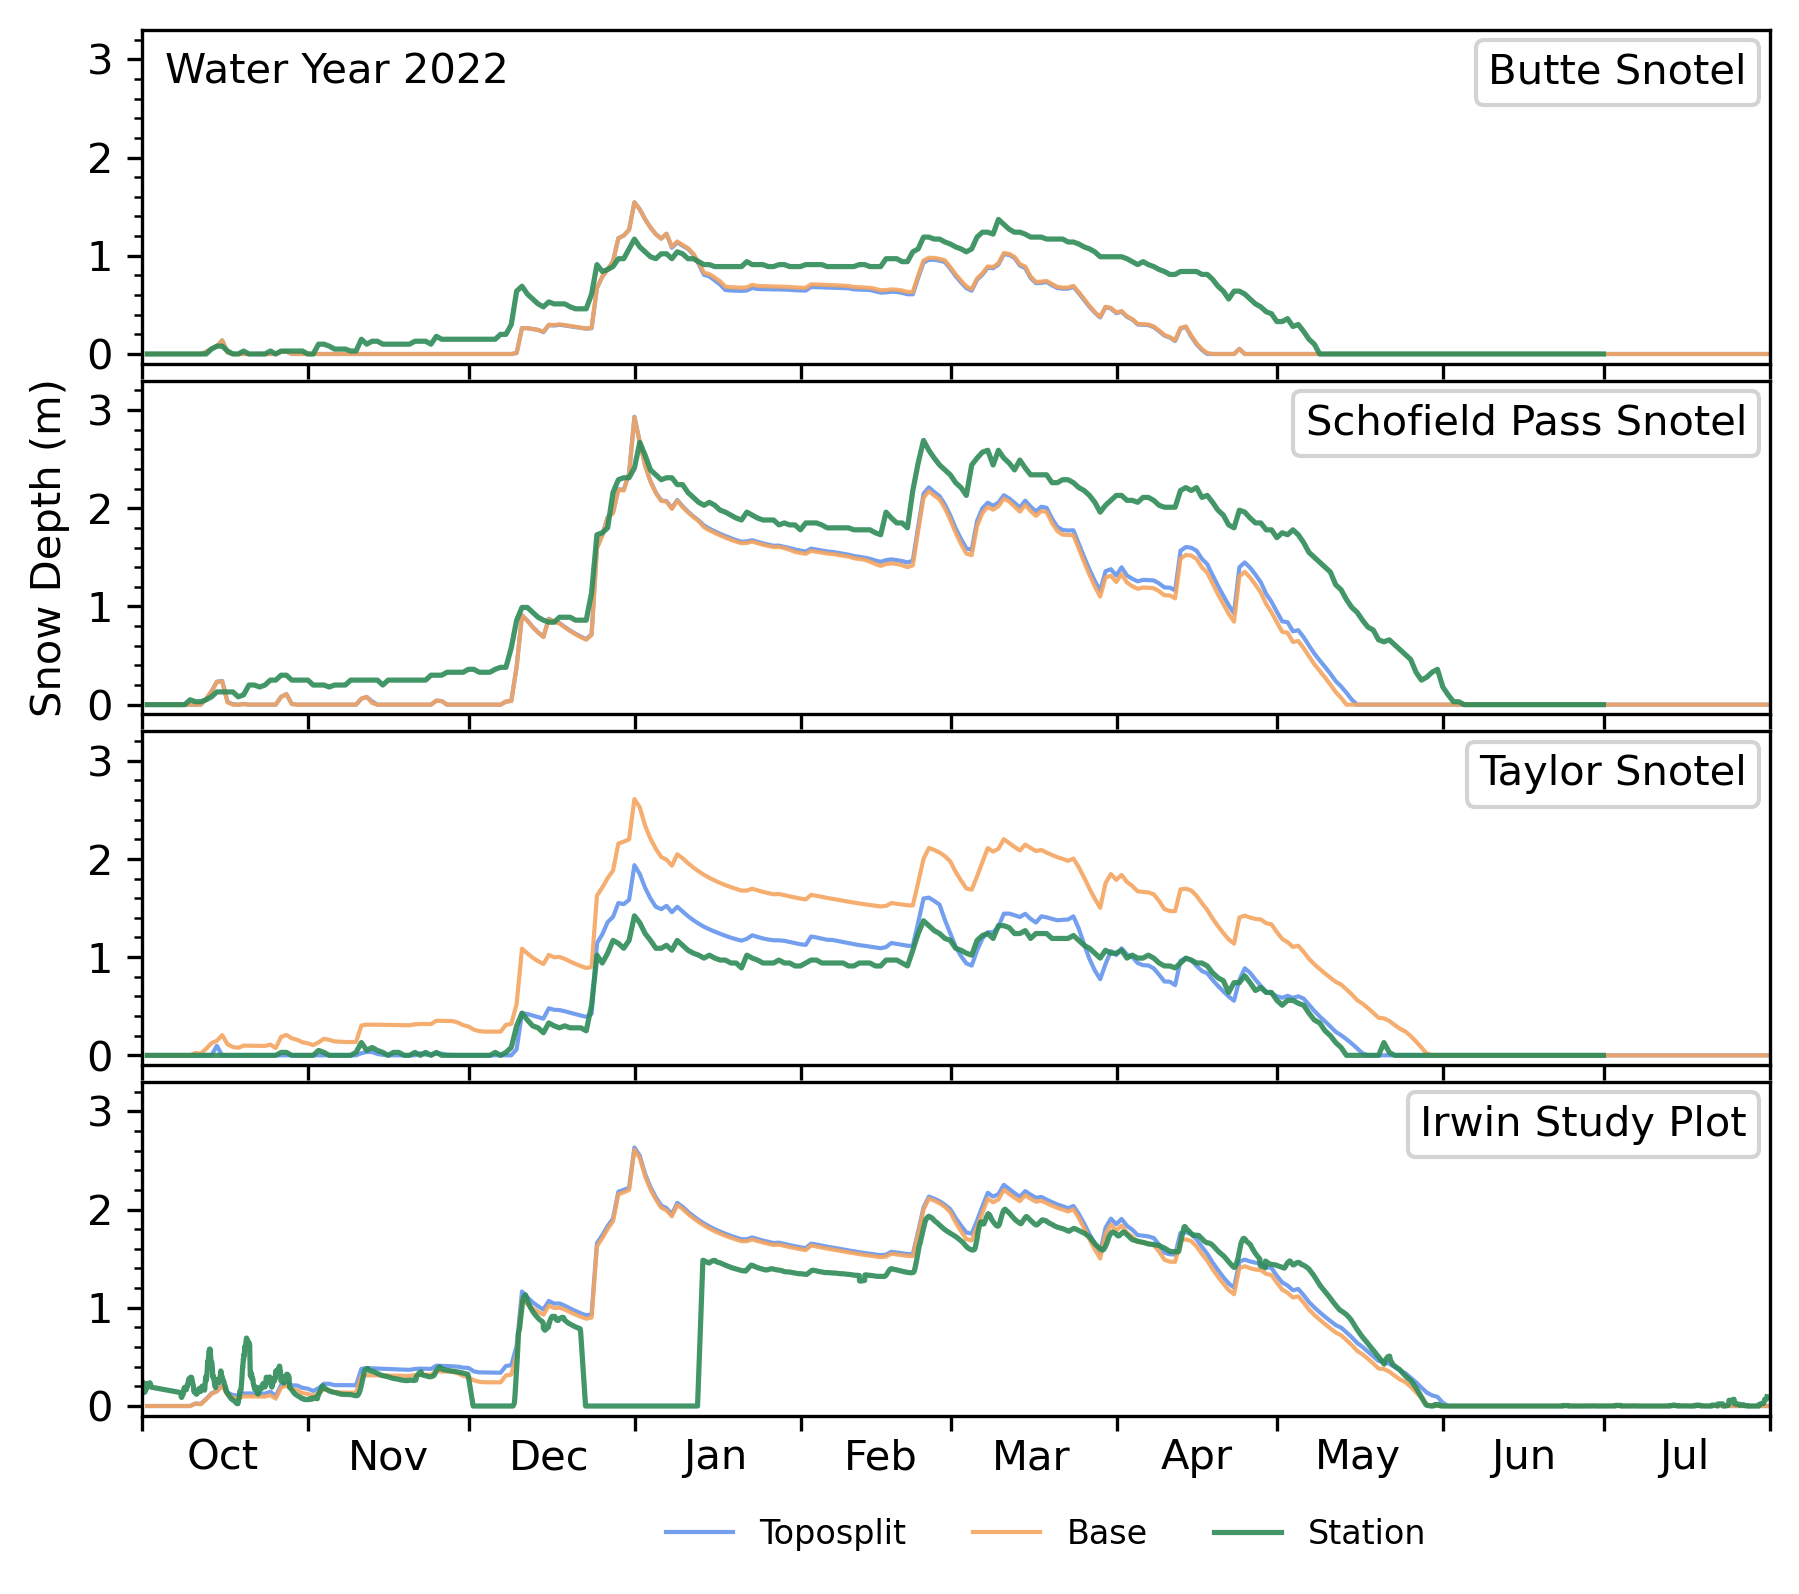

In [74]:
periods = 10 if year == 2021 else 11
plot_range = pd.date_range(start=f'{year - 1}-10-01', periods=periods, freq='MS')
xTicks = mdates.DateFormatter('%b')

figure_opts = dict(figsize=(7,6), dpi=300,)
fig, axes = plt.subplots(4, 1, sharex=True, **figure_opts)
plt.subplots_adjust(hspace=0.05)

plot_site(
    {
        'Toposplit': butte_snobal_dsw3h['thickness'],
        # 'Toposplit-flat': butte_snobal_dsw3h['thickness'],
        'Base': butte_snobal_ghi['thickness'],
        STATION_LABEL: butte_snotel_csv['Depth(m)'],
    },
    axes[0],
    'Butte Snotel'
)

# if year == 2022:
#     aso_marker=dict(label='ASO', marker='v', c='black', s=10)
#     axes[0].scatter(
#         [np.datetime64('2022-04-21'), np.datetime64('2022-05-18')],
#         [0.53, 0.03],
#         **aso_marker
#     )

plot_site(
    {
        'Toposplit': schofield_snobal_dsw3h['thickness'],
        # 'Toposplit-flat': schofield_snobal_dsw3h['thickness'],
        'Base': schofield_snobal_ghi['thickness'],
        STATION_LABEL: schofield_snotel_csv['Depth(m)'],
    },
    axes[1],
    'Schofield Pass Snotel'
)

plot_site(
    {
        'Toposplit': taylor_snobal_dsw3h['thickness'],
        # 'Toposplit-flat': taylor_snobal_dsw3h['thickness'],
        'Base': irwin_snobal_ghi['thickness'],
        STATION_LABEL: taylor_snotel_csv['Depth(m)'].rolling('1D').mean(),
    },
    axes[2],
    'Taylor Snotel'
)

plot_site(
    {
        'Toposplit': irwin_snobal_dsw3h['thickness'],
        # 'Toposplit-flat': irwin_snobal_dsw3h['thickness'],
        'Base': irwin_snobal_ghi['thickness'],
        STATION_LABEL: irwin_csv['Depth(m)'].rolling('1D').mean(),
    },
    axes[3],
    'Irwin Study Plot'
)
# if year == 2022:
#     axes[1].scatter( [], [], **aso_marker)

axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=16))
axes[1].xaxis.set_major_formatter(mticker.NullFormatter())
axes[1].xaxis.set_minor_formatter(xTicks)
axes[1].tick_params(axis='x', which='minor', pad=-0.5)

axes[1].set_ylabel(r'Snow Depth (m)')

at = AnchoredText(
    f'Water Year {year}', 
    prop=dict(size=10), 
    frameon=False, 
    loc='upper left', 
    pad=0.3, 
    borderpad=0.25,
)
axes[0].add_artist(at)
axes[3].legend(
    frameon=False,
    bbox_to_anchor=(0.80, -0.25),
    ncol=5,
    borderaxespad=0.15, 
    fontsize=8
);


svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
plt.savefig(svpth + 'fig-snotel-models2.png', dpi=300, bbox_inches='tight')

# Plot difference

In [65]:
def plot_site_diff(data, ax, site_name, return_legend_items=False):
    station_series = data[STATION_LABEL]
    # station_time = station_series.index  # pandas.DatetimeIndex
    station_time = station_series.index.tz_localize(None).to_numpy()

    legend_items = []

    for key in data:
        if key == STATION_LABEL:
            continue

        model_series = data[key]

        # Interpolate model to station times using xarray
        model_interp = model_series.interp(time=station_time)

        # Subtract: model - obs
        model_vals = model_interp.values.flatten()
        obs_vals = station_series.values.flatten()

        if len(model_vals) != len(obs_vals):
            raise ValueError(f"Length mismatch after interpolation: model={len(model_vals)} vs obs={len(obs_vals)}")

        diff = model_vals - obs_vals

        line, = ax.plot(
            station_time,
            diff,
            label=key,
            color=COLORS[key],
            alpha=0.9,
            lw=1
        )
        if return_legend_items:
            legend_items.append(line)

    # ax.set_ylabel(r'Snow depth difference (m)')
    ax.set_ylabel('')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.tick_params(axis='x', which='minor', tick1On=False, tick2On=False)
    ax.set_xlim([plot_range[0], plot_range[-1]])
    ax.set_ylim(-1.5, 1.5)
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.1))

    at = AnchoredText(
        site_name,
        prop=dict(size=10),
        frameon=True,
        loc='upper right',
        pad=0.3,
        borderpad=0.25,
    )
    at.patch.set_boxstyle("round", pad=0., rounding_size=0.2)
    at.patch.set(edgecolor='lightgrey')
    ax.add_artist(at)

    if return_legend_items:
        return legend_items


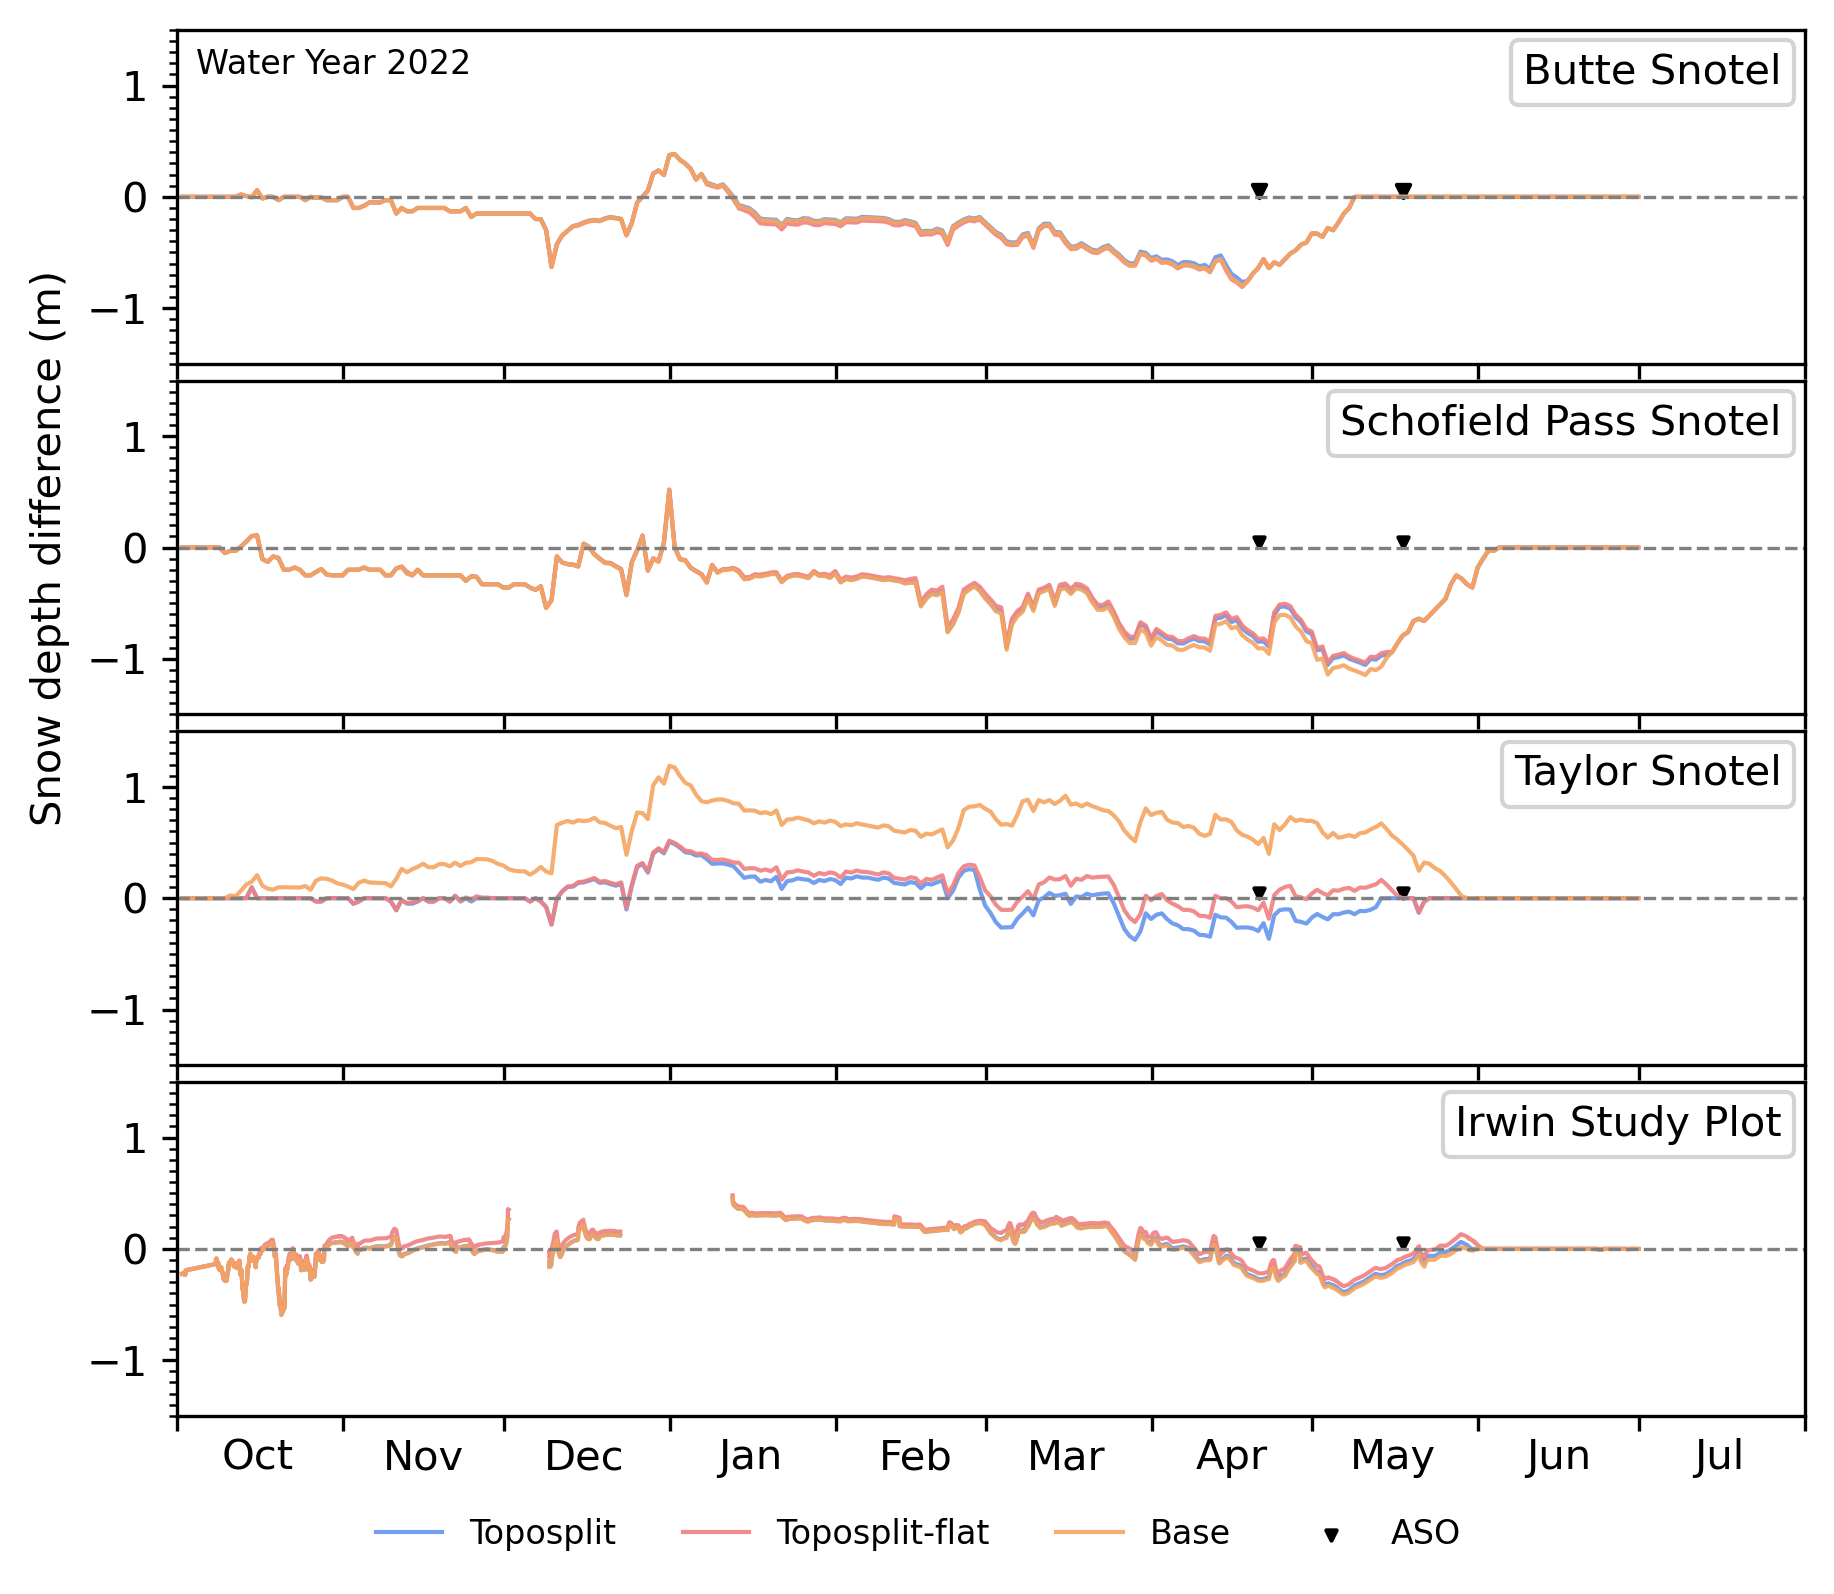

In [70]:
periods = 10 if year == 2021 else 11
plot_range = pd.date_range(start=f'{year - 1}-10-01', periods=periods, freq='MS')
xTicks = mdates.DateFormatter('%b')

figure_opts = dict(figsize=(7,6), dpi=300,)
fig, axes = plt.subplots(4, 1, sharex=True, **figure_opts)
plt.subplots_adjust(hspace=0.05)


# legend_lines = plot_site_diff(
#     {
#         'Toposplit': butte_snobal_dsw3['thickness'],
#         'Toposplit-flat': butte_snobal_dsw3h['thickness'],
#         'Base': butte_snobal_ghi['thickness'],
#         STATION_LABEL: butte_snotel_csv['Depth(m)'],
#     },
#     axes[3],
#     'Butte Snotel',
#     return_legend_items=True
# )

# Add legend just to the first subplot
# axes[0].legend(
#     handles=legend_lines,
#     frameon=False,
#     loc='upper left',
#     ncol=3,
#     fontsize=8,
#     borderaxespad=0.2
# )


plot_site_diff(
    {
        'Toposplit': butte_snobal_dsw3['thickness'],
        'Toposplit-flat': butte_snobal_dsw3h['thickness'],
        'Base': butte_snobal_ghi['thickness'],
        STATION_LABEL: butte_snotel_csv['Depth(m)'],
    },
    axes[0],
    'Butte Snotel'
)

if year == 2022:
    aso_marker=dict(label='ASO', marker='v', c='black', s=10)
    axes[0].scatter(
        [np.datetime64('2022-04-21'), np.datetime64('2022-05-18')],
        [0.05, 0.05],
        **aso_marker
    )
# if year == 2022:
#     aso_marker = dict(label='ASO', marker='v', c='black', s=6)
#     aso_scatter = axes[0].scatter(
#         [np.datetime64('2022-04-21'), np.datetime64('2022-05-18')],
#         [0.05, 0.05],
#         **aso_marker
#     )
#      # Add to legend manually if needed
#     axes[0].legend(
#         handles=[*legend_lines, aso_scatter],  # Combine model lines + ASO marker
#         frameon=False,
#         loc='upper left',
#         ncol=4,
#         fontsize=8,
#         borderaxespad=0.2
#     )


plot_site_diff(
    {
        'Toposplit': schofield_snobal_dsw3['thickness'],
        'Toposplit-flat': schofield_snobal_dsw3h['thickness'],
        'Base': schofield_snobal_ghi['thickness'],
        STATION_LABEL: schofield_snotel_csv['Depth(m)'],
    },
    axes[1],
    'Schofield Pass Snotel'
)

plot_site_diff(
    {
        'Toposplit': taylor_snobal_dsw3['thickness'],
        'Toposplit-flat': taylor_snobal_dsw3h['thickness'],
        'Base': irwin_snobal_ghi['thickness'],
        STATION_LABEL: taylor_snotel_csv['Depth(m)'].rolling('1D').mean(),
    },
    axes[2],
    'Taylor Snotel'
)

# Copy the series to avoid changing original data
irwin_depth = irwin_csv['Depth(m)'].copy()
irwin_depth = irwin_depth.loc[:'2022-06-30']
# Define date range mask
mask = (irwin_depth.index >= '2021-12-01') & (irwin_depth.index <= '2022-01-20')
# Set 0 values in that range to NaN
irwin_depth.loc[mask & (irwin_depth == 0)] = np.nan



plot_site_diff(
    {
        'Toposplit': irwin_snobal_dsw3['thickness'],
        'Toposplit-flat': irwin_snobal_dsw3h['thickness'],
        'Base': irwin_snobal_ghi['thickness'],
        # STATION_LABEL: irwin_csv['Depth(m)'].rolling('1D').mean(),
        STATION_LABEL: irwin_depth.rolling('1D').mean(),
    },
    axes[3],
    'Irwin Study Plot'
)
# if year == 2022:
#     axes[1].scatter( [], [], **aso_marker)

aso_marker=dict(label='ASO', marker='v', c='black', s=6)
axes[1].scatter(
    [np.datetime64('2022-04-21'), np.datetime64('2022-05-18')],
    [0.05, 0.05],
    **aso_marker
)
axes[2].scatter(
    [np.datetime64('2022-04-21'), np.datetime64('2022-05-18')],
    [0.05, 0.05],
    **aso_marker
)
axes[3].scatter(
    [np.datetime64('2022-04-21'), np.datetime64('2022-05-18')],
    [0.05, 0.05],
    **aso_marker
)


axes[1].set_ylabel(r'Snow depth difference (m)')

axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=16))
axes[1].xaxis.set_major_formatter(mticker.NullFormatter())
axes[1].xaxis.set_minor_formatter(xTicks)
axes[1].tick_params(axis='x', which='minor', pad=-0.5)

at = AnchoredText(
    f'Water Year {year}', 
    prop=dict(size=8), 
    frameon=False, 
    loc='upper left', 
    pad=0.3, 
    borderpad=0.25,
)
axes[0].add_artist(at)
# fig.supxlabel(f'Water Year {year}', fontsize=10)

axes[3].legend(
    frameon=False,
    bbox_to_anchor=(0.80, -0.25),
    ncol=5,
    borderaxespad=0.15, 
    fontsize=8
);
# final_legend_items = legend_lines.copy()
# if aso_scatter:
#     final_legend_items.append(aso_scatter)
# axes[3].legend(
#     handles=final_legend_items,
#     frameon=False,
#     loc='lower left',
#     bbox_to_anchor=(0.0, -0.15),  
#     ncol=4,
#     fontsize=8
# )

# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'fig-snotel-diff-models.png', dpi=300, bbox_inches='tight')
